In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

# =========================
# 1. Data Loading
# =========================
file_mapping = {
    "Native": ["results/new/native5.csv", "results/new/native5_2.csv"],
    "SME":    ["results/new/sme5.csv",    "results/new/sme5_2.csv"],
    "SEV":    ["results/new/sev5.csv",    "results/new/sev5_2.csv"],
}

dfs = []
for env, paths in file_mapping.items():
    for i, p in enumerate(paths):
        path_obj = Path(p)
        if path_obj.exists():
            df = pd.read_csv(path_obj)
            df["env"] = env
            # Vereinheitlichte Batch-ID: B1 für die erste Datei, B2 für die zweite
            df["batch_id"] = f"B{i+1}"
            dfs.append(df)

data = pd.concat(dfs, ignore_index=True)
group_cols = ["env", "matrix_path", "n_cores", "config"]

# =========================
# 2. Instability & Outlier Removal
# =========================
def remove_gflops_outliers(df):
    def filter_group(group):
        if len(group) < 3: return group
        q1, q3 = group["gflops"].quantile([0.25, 0.75])
        iqr = q3 - q1
        return group[(group["gflops"] >= (q1 - 1.5 * iqr)) & (group["gflops"] <= (q3 + 1.5 * iqr))]
    return df.groupby(group_cols + ["batch_id"], group_keys=False).apply(filter_group)

data_clean = remove_gflops_outliers(data)

# Aggregation: Median pro Batch (für den Batch-Plot)
agg_batch = data_clean.groupby(group_cols + ["batch_id"], as_index=False)["gflops"].median()

# Aggregation: Globaler Median (für den Standard-Pivot)
agg_total = data_clean.groupby(group_cols, as_index=False)["gflops"].median()
pivot_df = agg_total.pivot(index=["matrix_path", "n_cores", "config"], columns="env", values="gflops").reset_index()

print(f"Daten geladen. Batches identifiziert: {agg_batch['batch_id'].unique()}")

Daten geladen. Batches identifiziert: ['B1' 'B2']


/tmp/ipykernel_1893310/1899534436.py:38: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(group_cols + ["batch_id"], group_keys=False).apply(filter_group)


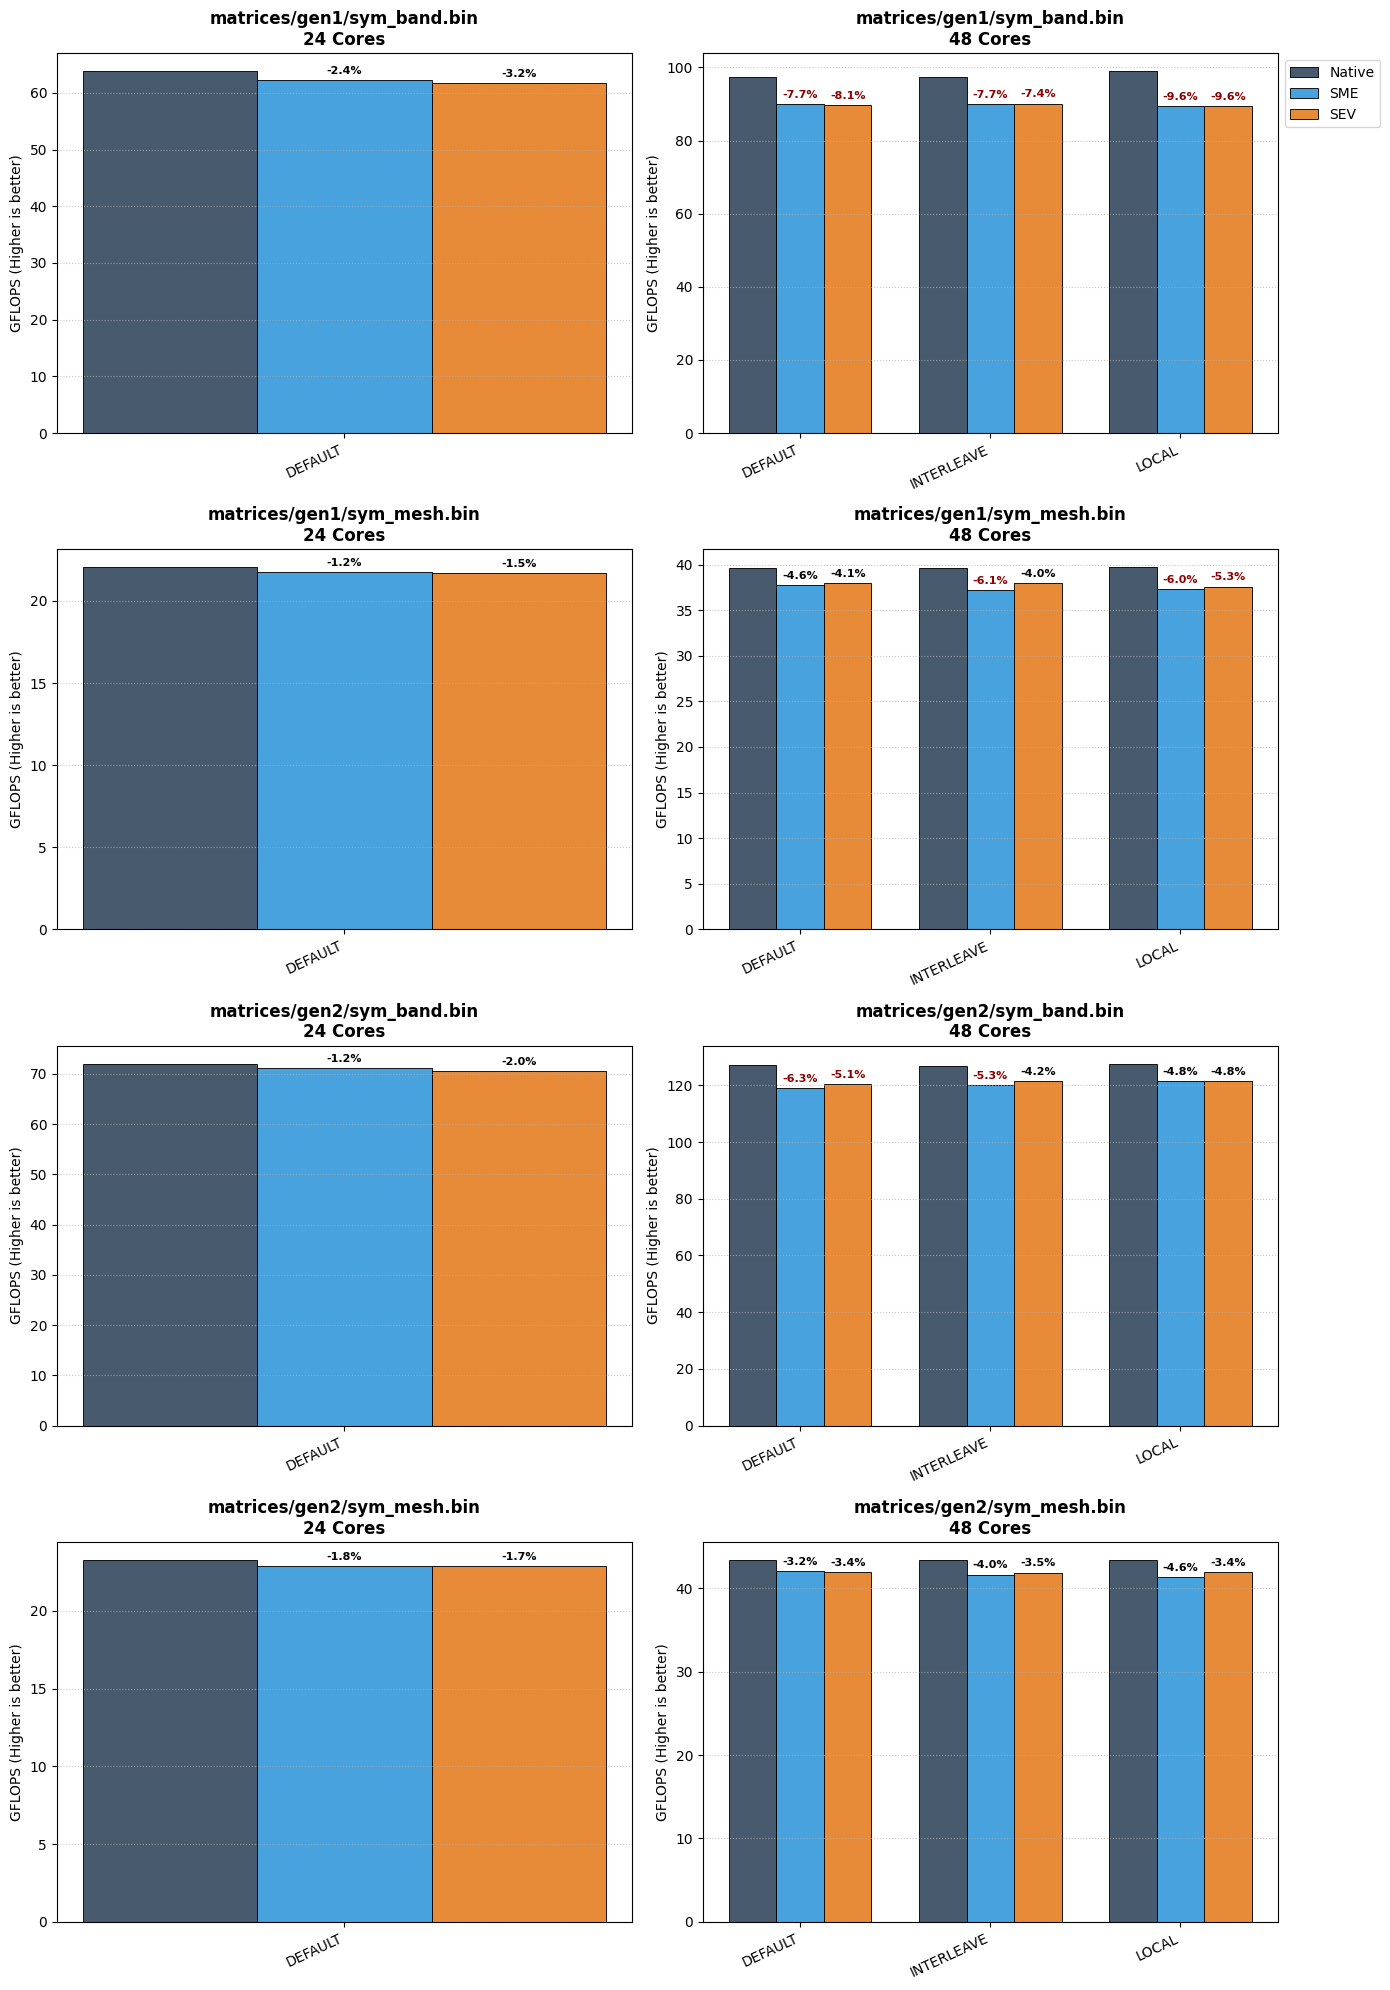

In [3]:
# =========================
# 4. Plotting
# =========================
matrices = sorted(pivot_df["matrix_path"].unique())
core_counts = sorted(pivot_df["n_cores"].unique())
envs_to_plot = ["Native", "SME", "SEV"]
colors = {"Native": "#34495e", "SME": "#3498db", "SEV": "#e67e22"}

fig, axes = plt.subplots(
    len(matrices), len(core_counts), 
    figsize=(7 * len(core_counts), 5 * len(matrices)), 
    squeeze=False
)

for i, matrix in enumerate(matrices):
    for j, cores in enumerate(core_counts):
        ax = axes[i][j]
        subset = pivot_df[(pivot_df["matrix_path"] == matrix) & (pivot_df["n_cores"] == cores)]
        
        if subset.empty:
            ax.set_visible(False)
            continue

        configs = sorted(subset["config"].unique())
        x = np.arange(len(configs))
        bar_width = 0.25

        for k, env in enumerate(envs_to_plot):
            if env not in subset.columns: continue
            
            y_values = [subset[subset["config"] == cfg][env].values[0] for cfg in configs]
            bars = ax.bar(x + k * bar_width, y_values, width=bar_width, label=env, 
                          color=colors[env], alpha=0.9, edgecolor='black', linewidth=0.7)
            
            # Annotate Overhead
            if env in ["SME", "SEV"]:
                for idx, bar in enumerate(bars):
                    native_val = subset[subset["config"] == configs[idx]]["Native"].values[0]
                    current_val = bar.get_height()
                    if current_val > 0 and native_val > 0:
                        drop = (current_val / native_val - 1) * 100
                        ax.annotate(f'{drop:+.1f}%',
                                    xy=(bar.get_x() + bar.get_width() / 2, current_val),
                                    xytext=(0, 3), textcoords="offset points",
                                    ha='center', va='bottom', fontsize=8, fontweight='bold',
                                    color='darkred' if drop < -5 else 'black')

        ax.set_title(f"{matrix}\n{cores} Cores", fontweight='bold')
        ax.set_xticks(x + bar_width)
        ax.set_xticklabels(configs, rotation=25, ha="right")
        ax.set_ylabel("GFLOPS (Higher is better)")
        ax.grid(axis='y', linestyle=':', alpha=0.7)
        if i == 0 and j == len(core_counts)-1:
            ax.legend(loc='upper left', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

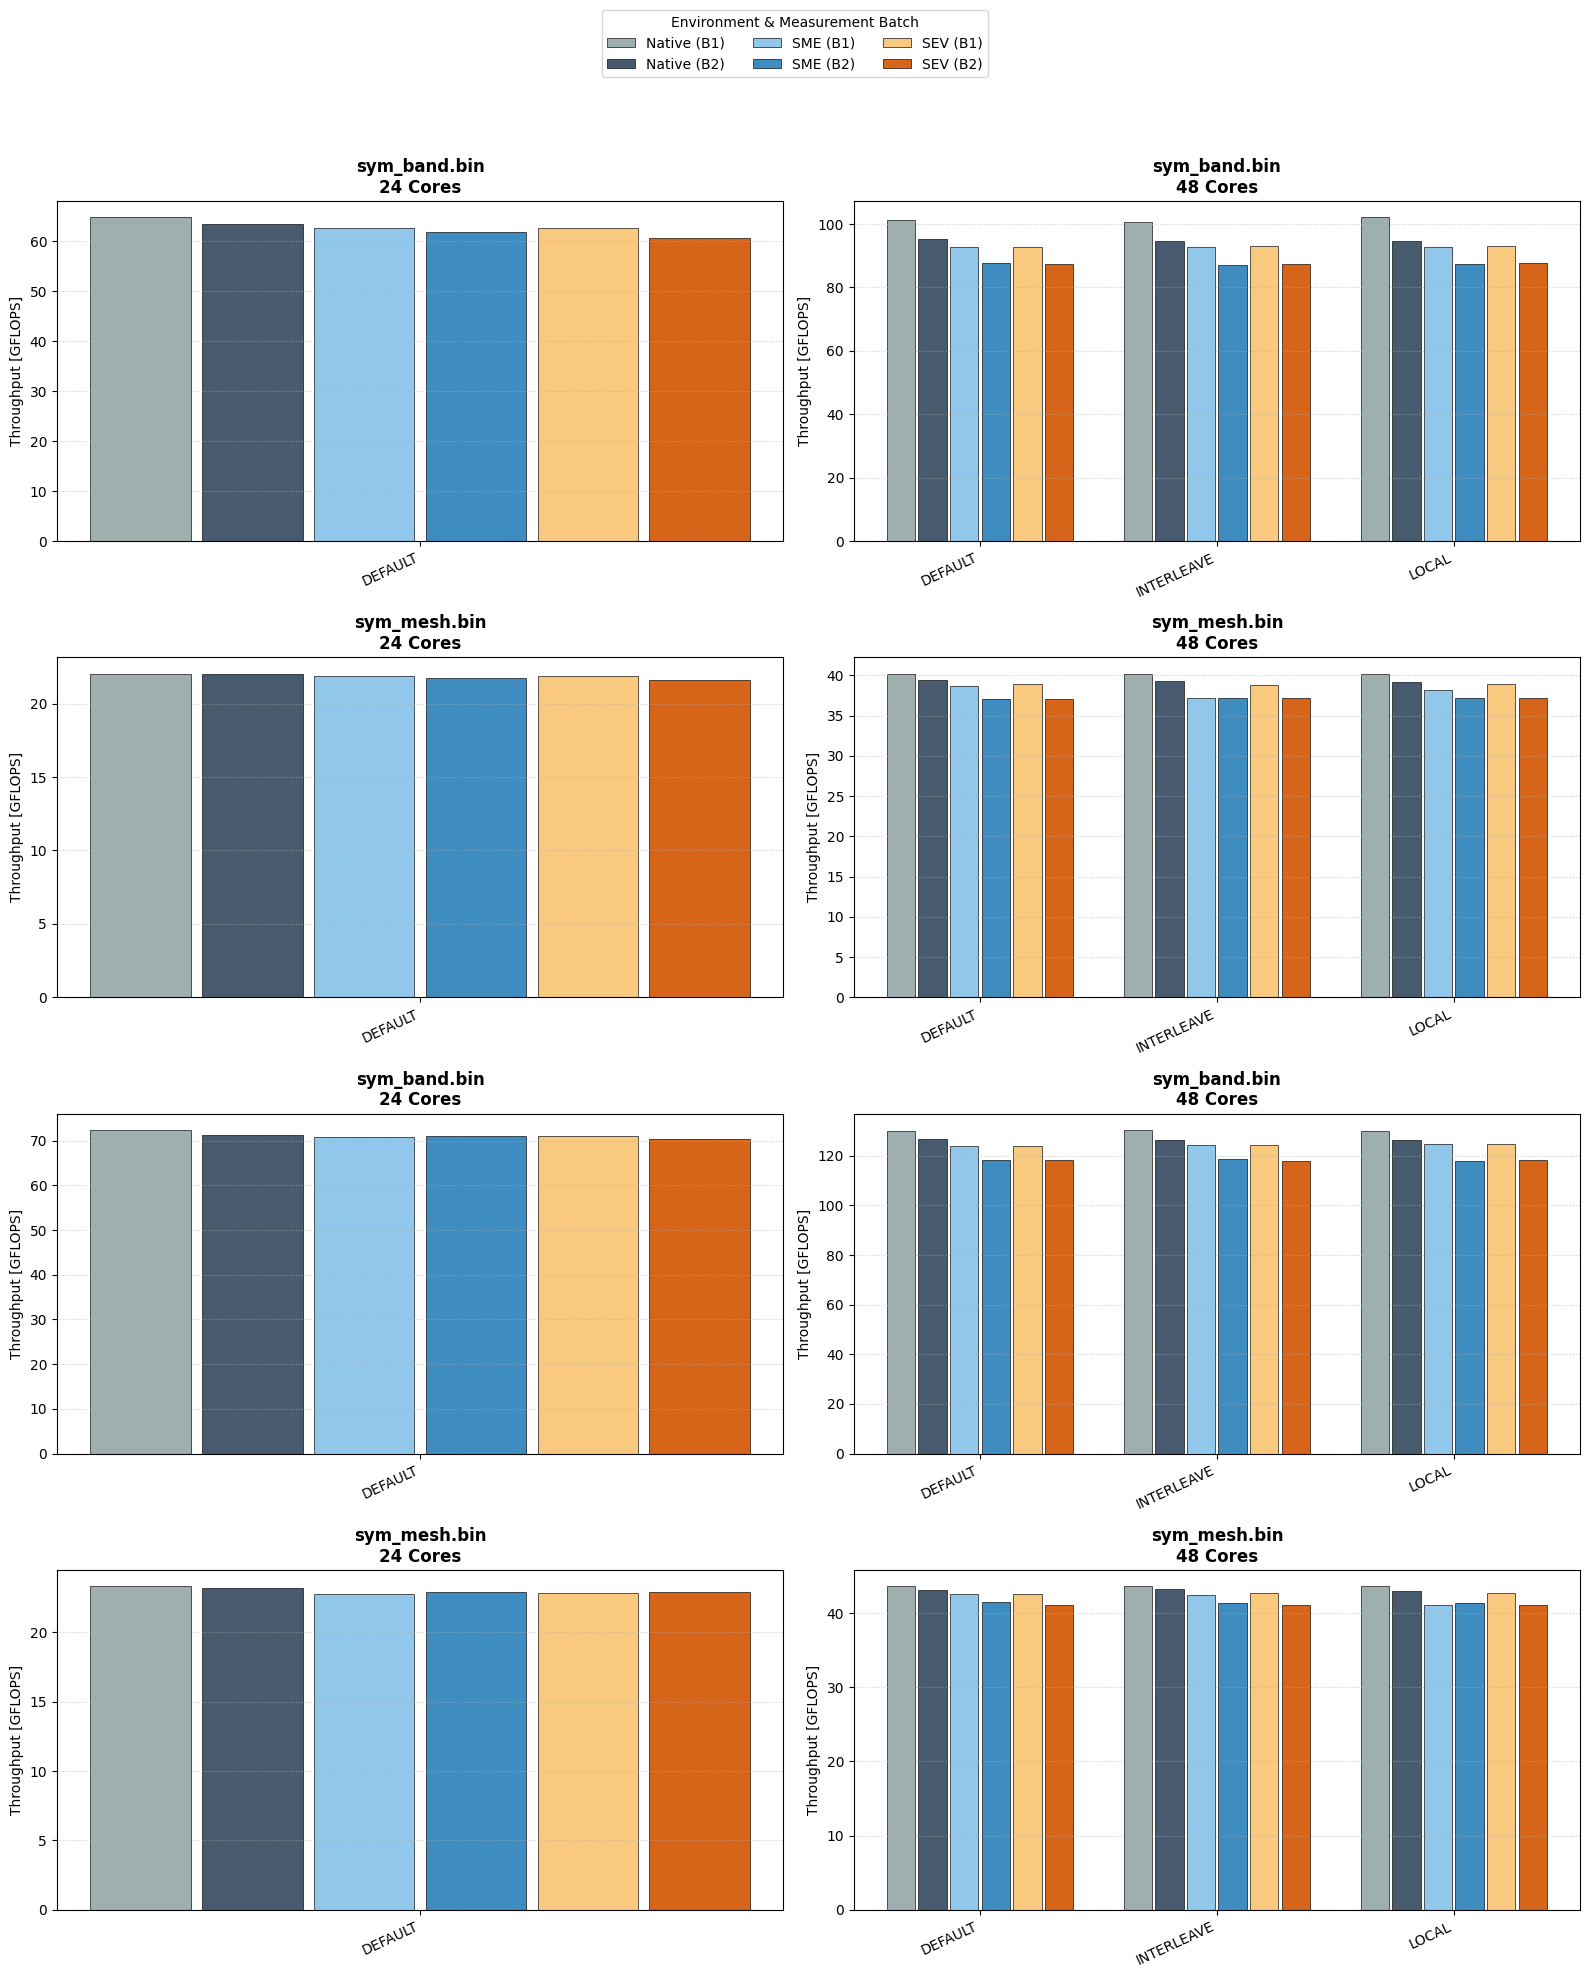

In [8]:
# =========================
# 3. Batch Comparison Plot (Fixed Legend)
# =========================
matrices = sorted(agg_batch["matrix_path"].unique())
core_counts = sorted(agg_batch["n_cores"].unique())
envs = ["Native", "SME", "SEV"]
batch_ids = sorted(agg_batch["batch_id"].unique())

# Farben: Batch 1 (hell), Batch 2 (dunkel)
colors = {
    "Native": ["#95a5a6", "#34495e"],
    "SME":    ["#85c1e9", "#2980b9"],
    "SEV":    ["#f8c471", "#d35400"]
}

fig, axes = plt.subplots(len(matrices), len(core_counts), 
                         figsize=(8 * len(core_counts), 5 * len(matrices)), squeeze=False)

# Wir sammeln hier einmalig die Handles für die Legende
legend_handles = []

for i, matrix in enumerate(matrices):
    for j, cores in enumerate(core_counts):
        ax = axes[i][j]
        subset = agg_batch[(agg_batch["matrix_path"] == matrix) & (agg_batch["n_cores"] == cores)]
        
        if subset.empty:
            ax.set_axis_off() # Schaltet den Plot sauber aus
            continue

        configs = sorted(subset["config"].unique())
        x = np.arange(len(configs))
        
        total_width = 0.8
        env_width = total_width / len(envs)
        b_width = env_width / len(batch_ids)

        for k, env in enumerate(envs):
            for b_idx, b_id in enumerate(batch_ids):
                b_data = subset[(subset["env"] == env) & (subset["batch_id"] == b_id)]
                if b_data.empty: continue
                
                y_vals = [b_data[b_data["config"] == cfg]["gflops"].values[0] if not b_data[b_data["config"] == cfg].empty else 0 for cfg in configs]
                
                pos = x + (k * env_width) + (b_idx * b_width)
                bar = ax.bar(pos, y_vals, width=b_width * 0.9, # 0.9 für einen kleinen Spalt zwischen Batches
                       color=colors[env][b_idx], edgecolor='black', linewidth=0.5, alpha=0.9)
                
                # Nur beim allerersten Plot sammeln wir die Legenden-Einträge
                if i == 0 and j == 0:
                    legend_handles.append(bar[0])

        ax.set_title(f"{Path(matrix).name}\n{cores} Cores", fontweight='bold', fontsize=12)
        ax.set_xticks(x + total_width/2 - b_width/2)
        ax.set_xticklabels(configs, rotation=25, ha="right")
        ax.set_ylabel("Throughput [GFLOPS]")
        ax.grid(axis='y', linestyle=':', alpha=0.6)

# Globale Legende oben oder rechts platzieren
labels = [f"{env} ({b})" for env in envs for b in batch_ids]
fig.legend(legend_handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.02), 
           ncol=3, title="Environment & Measurement Batch", frameon=True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Platz für die Legende oben lassen
plt.show()

In [9]:
# =========================
# 4. Batch Analysis Table
# =========================

# Wir nutzen agg_batch für die Einzelwerte und agg_total für den Native-Referenzwert
table_df = agg_batch.pivot(
    index=["matrix_path", "n_cores", "config", "env"], 
    columns="batch_id", 
    values="gflops"
).reset_index()

# Berechne die prozentuale Abweichung zwischen B1 und B2 (Reproduzierbarkeit)
table_df['Batch_Diff_%'] = ((table_df['B2'] / table_df['B1'] - 1) * 100).round(2)

# Um den Drop berechnen zu können, brauchen wir den Native-Schnitt als Referenz
native_ref = agg_total[agg_total["env"] == "Native"].copy()
native_ref = native_ref.rename(columns={"gflops": "native_avg"})
table_df = table_df.merge(native_ref[["matrix_path", "n_cores", "config", "native_avg"]], 
                          on=["matrix_path", "n_cores", "config"], how="left")

# Berechne den Drop gegenüber Native (Durchschnitt beider Batches)
table_df['Drop_vs_Native_%'] = (( (table_df['B1'] + table_df['B2'])/2 / table_df['native_avg'] - 1) * 100).round(2)

# Formatierung der Matrix-Pfade für bessere Lesbarkeit
table_df["matrix"] = table_df["matrix_path"].apply(lambda x: Path(x).name)

# Sortierung und Auswahl der relevanten Spalten
final_table = table_df[[
    "matrix", "n_cores", "config", "env", "B1", "B2", "Batch_Diff_%", "Drop_vs_Native_%"
]].sort_values(by=["matrix", "n_cores", "config", "env"])

# Ausgabe der Tabelle (kannst du direkt kopieren)
print("--- Batch-Vergleich und Performance-Drop Tabelle ---")
print(final_table.to_string(index=False))

# Optional: Export als CSV für Excel/Masterarbeit
# final_table.to_csv("batch_analysis_results.csv", index=False)

--- Batch-Vergleich und Performance-Drop Tabelle ---
      matrix  n_cores     config    env        B1        B2  Batch_Diff_%  Drop_vs_Native_%
sym_band.bin       24    DEFAULT Native  64.73370  63.41110         -2.04              0.40
sym_band.bin       24    DEFAULT Native  72.44070  71.29260         -1.58             -0.24
sym_band.bin       24    DEFAULT    SEV  62.59480  60.66270         -3.09             -3.43
sym_band.bin       24    DEFAULT    SEV  71.07380  70.33650         -1.04             -1.85
sym_band.bin       24    DEFAULT    SME  62.54705  61.72200         -1.32             -2.64
sym_band.bin       24    DEFAULT    SME  70.82060  71.16820          0.49             -1.45
sym_band.bin       48    DEFAULT Native 101.17800  95.13650         -5.97              0.67
sym_band.bin       48    DEFAULT Native 130.02500 126.85200         -2.44              0.96
sym_band.bin       48    DEFAULT    SEV  92.77300  87.44130         -5.75             -7.59
sym_band.bin       48    DE

In [23]:
# Berechnung für 1% Ziel-Genauigkeit
stats_raw = data.groupby(["matrix_path", "env", "n_cores", "config"])["gflops"].agg(["mean", "std"]).reset_index()

def get_n_1pct(row):
    mean, sigma = row["mean"], row["std"]
    if sigma == 0 or mean == 0 or np.isnan(sigma): return 1
    # D = 1% von Mean
    # N = 16 * (sigma / (0.01 * mean))**2
    return int(np.ceil(16 * (sigma / (0.01 * mean))**2))

stats_raw["N_req_1pct"] = stats_raw.apply(get_n_1pct, axis=1)

print("--- ANFORDERUNG FÜR 1% PRÄZISION ---")
print(f"Durchschnittlich benötigte Runs über alle Tests: {stats_raw['N_req_1pct'].mean():.1f}")
print("\n--- DIE 10 KRITISCHSTEN KONFIGURATIONEN (N für 1%) ---")
print(stats_raw.sort_values("N_req_1pct", ascending=False)[
    ["matrix_path", "env", "n_cores", "config", "N_req_1pct"]
].head(10).to_string(index=False))

--- ANFORDERUNG FÜR 1% PRÄZISION ---
Durchschnittlich benötigte Runs über alle Tests: 72.3

--- DIE 10 KRITISCHSTEN KONFIGURATIONEN (N für 1%) ---
               matrix_path    env  n_cores     config  N_req_1pct
matrices/gen1/sym_band.bin Native       48      LOCAL         307
matrices/gen1/sym_band.bin Native       48 INTERLEAVE         235
matrices/gen1/sym_band.bin Native       48    DEFAULT         193
matrices/gen1/sym_band.bin    SEV       48 INTERLEAVE         183
matrices/gen1/sym_band.bin    SEV       48    DEFAULT         150
matrices/gen1/sym_band.bin    SME       48      LOCAL         150
matrices/gen2/sym_band.bin    SEV       48      LOCAL         149
matrices/gen2/sym_band.bin    SEV       48 INTERLEAVE         149
matrices/gen1/sym_band.bin    SEV       48      LOCAL         143
matrices/gen1/sym_band.bin    SME       48 INTERLEAVE         141
